In [1]:
import os
import json
import cv2
import torch
import random
import scipy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import fftpack as fft
from PIL import Image, ImageOps
from tqdm import tqdm
from timm.scheduler.cosine_lr import CosineLRScheduler
from timm.models import maxxvit
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.optim as optim
import torchvision.transforms as T
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [3]:
import seaborn as sns

In [4]:
# Define the paths
train_npy_path = "/kaggle/input/signal-fast-radio-burst-detection/train/train"
train_csv_path = "/kaggle/input/signal-fast-radio-burst-detection/train-labels-corrected/train"
test_npy_path = "/kaggle/input/signal-fast-radio-burst-detection/test/test"
output_dir = "/kaggle/working"

In [5]:
train_dir = os.path.join(output_dir, "train_dir")
test_dir = os.path.join(output_dir, "test_dir")

# Create output directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [6]:
# Load CSV files
csv_files = [f for f in os.listdir(train_csv_path) if f.endswith('.csv')]
train_df = pd.DataFrame(columns=['index', 'image', 'label'])

# Process each .npy file and corresponding .csv file
for csv_file in csv_files:
    npy_file = csv_file.replace('_labels.csv', '.npy')
    npy_data = np.load(os.path.join(train_npy_path, npy_file))  # Shape: (262144, 256)
    csv_data = pd.read_csv(os.path.join(train_csv_path, csv_file))
    
    # Slice the npy_data into chunks of 256x256
    num_chunks = npy_data.shape[0] // 256  # 262144 / 256 = 1024 chunks
    for chunk_idx in range(num_chunks):
        # Extract a 256x256 chunk
        chunk = npy_data[chunk_idx * 256 : (chunk_idx + 1) * 256, :]  # Shape: (256, 256)
        
        # Save the chunk as an image
        image_path = os.path.join(output_dir, f"{npy_file.replace('+', '_').replace('-', '_').replace('.npy', '')}_{chunk_idx}.jpg")
        plt.imsave(image_path, chunk, cmap='gray')
        
        # Get the corresponding label from the CSV file
        label = csv_data.iloc[chunk_idx]['labels']
        
        # Append the new row to the DataFrame using pd.concat
        new_row = pd.DataFrame([{'index': f"{npy_file.replace('+', '_').replace('-', '_').replace('.npy', '')}_{chunk_idx}", 'image': image_path, 'label': label}])
        train_df = pd.concat([train_df, new_row], ignore_index=True)

In [7]:
train_df.to_csv('/kaggle/working/train_input_df.csv', index=False)
print(train_df.head(2))

                                       index  \
0  B1933_16_59475_68410_reduced_fc_0001023_0   
1  B1933_16_59475_68410_reduced_fc_0001023_1   

                                               image label  
0  /kaggle/working/B1933_16_59475_68410_reduced_f...   NaN  
1  /kaggle/working/B1933_16_59475_68410_reduced_f...   NaN  


In [8]:
train_df["label"].value_counts()

# ดูเปอร์เซนต์แทนจำนวน
train_df["label"].value_counts(normalize=True)

# ดู dataframe
label_distribution = train_df["label"].value_counts().reset_index()
label_distribution.columns = ["Label", "Count"]
print(label_distribution)

           Label  Count
0      Unlabeled  11842
1         Narrow   8582
2      Uncertain   5721
3          Pulse   3847
4          Broad   3201
5   Narrow+Broad    138
6   Narrow+Pulse     60
7  Unknown+Pulse     37
8    Broad+Pulse      9


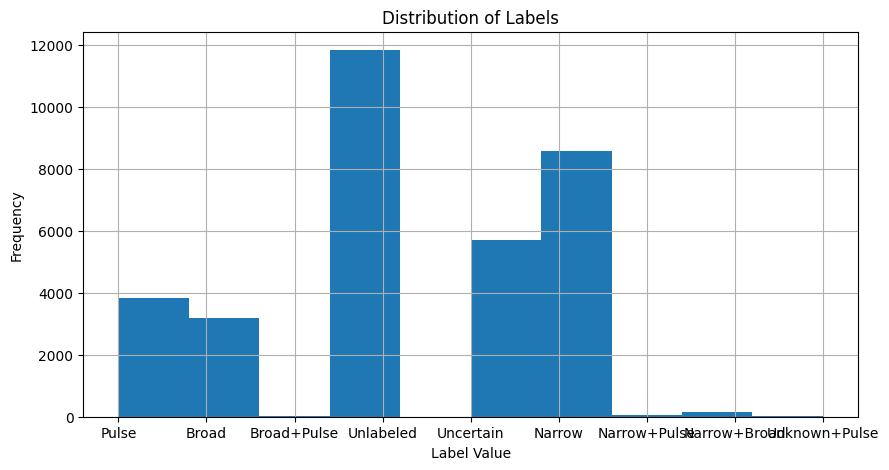

In [9]:
# Alternative, slightly more concise approach (but less flexible):
plt.figure(figsize=(10, 5)) # Create the figure *before* the hist call
train_df['label'].hist()
plt.title('Distribution of Labels')
plt.xlabel('Label Value')
plt.ylabel('Frequency')
plt.show()

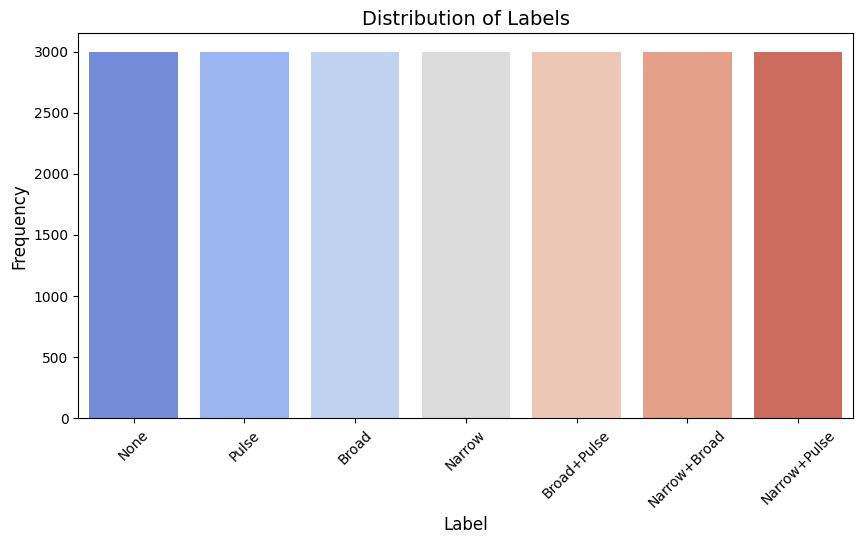

label
None            3000
Pulse           3000
Broad           3000
Narrow          3000
Broad+Pulse     3000
Narrow+Broad    3000
Narrow+Pulse    3000
Name: count, dtype: int64


In [10]:
# 1.ฟังก์ชันลบ Label ที่ไม่ต้องการ
def drop_unknown_labels(df):
    return df.query('label not in ["Uncertain", "Unlabeled"]')

train_df = drop_unknown_labels(train_df)

# 2.แทนค่าที่หายไปและเปลี่ยนค่า 0 เป็น "None"
train_df["label"] = train_df["label"].fillna("None").replace(0, "None")

# 3.ทำ Oversampling ให้ Label เท่ากัน
labels_to_balance = ["None", "Pulse", "Broad", "Narrow", "Broad+Pulse", "Narrow+Broad", "Narrow+Pulse"]
balanced_data = []
for label in labels_to_balance:
    if label in train_df["label"].unique():
        balanced_data.append(train_df[train_df["label"] == label].sample(n=3000, replace=True))

train_df = pd.concat(balanced_data, axis=0)

# 4.แสดงการกระจายของ Label
plt.figure(figsize=(10, 5))
sns.countplot(x=train_df["label"], palette="coolwarm")
plt.title("Distribution of Labels", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)  # หมุน Label ให้ดูง่ายขึ้น
plt.show()

# 5.ตรวจสอบว่าทุกคลาสมี 3000 ตัวอย่าง
print(train_df["label"].value_counts())

In [11]:
# 1.สร้าง Mapping จาก Label เป็นตัวเลข
label_mapping = {
    "None": 0,
    "Pulse": 1,
    "Broad": 2,
    "Narrow": 3,
    "Broad+Pulse": 4,
    "Narrow+Broad": 5,
    "Narrow+Pulse": 6
}

# 2.แปลง Label จากข้อความเป็นตัวเลข
train_df['label'] = train_df['label'].map(label_mapping).astype(int)

# 3.ตรวจสอบว่ามี Label ที่ไม่อยู่ใน Mapping หรือไม่
if train_df['label'].isnull().sum() > 0:
    print(train_df[train_df['label'].isnull()])
else:
    print("Label Correct!")

# 4.แบ่งข้อมูลเป็น Training Set และ Validation Set (90:10)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

# 5.แสดงขนาดของชุดข้อมูลที่แบ่ง
print(f"Training Set Size: {len(train_df)}")
print(f"Validation Set Size: {len(val_df)}")

Label Correct!
Training Set Size: 18900
Validation Set Size: 2100


In [12]:
# Define the ImageDataset class
class ImageDataset(Dataset):
    def __init__(self, dataframe, transforms, has_labels=True):
        self.dataframe = dataframe
        self.transforms = transforms
        self.has_labels = has_labels  # Flag to indicate whether labels are present

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row['image']

        # ตรวจสอบว่าไฟล์ภาพมีอยู่จริง
        if not os.path.exists(image_path):
            print(f"Warning: Missing image file {image_path}")
            return None

        try:
            image = Image.open(image_path).convert("RGB")  # เปิดภาพแบบ RGB
            image = self.transforms(image)  # ใช้การแปลงภาพ
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None

        if self.has_labels:
            label = torch.tensor(row['label'], dtype=torch.long)  # แปลง Label เป็น Tensor
            return image, label
        else:
            return image  # Return only the image if labels are not present

# Define transforms
img_size = (256, 256)
transforms = {
    "train": T.Compose([
        T.Resize(img_size, interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.234, 0.234, 0.234])
    ]),
    "test": T.Compose([
        T.Resize(img_size, interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.234, 0.234, 0.234])
    ]),
}

# Batch Size & num_workers
batch_size = 16
num_workers = os.cpu_count() // 2  # ใช้ครึ่งหนึ่งของ CPU cores

# Create Datasets
train_dataset = ImageDataset(train_df, transforms["train"], has_labels=True)
val_dataset = ImageDataset(val_df, transforms["test"], has_labels=True)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=True)

# Check DataLoader Output
for images, labels in train_loader:
    print(f"Batch Shape: {images.shape}, Labels: {labels.shape}")
    break

Batch Shape: torch.Size([16, 3, 256, 256]), Labels: torch.Size([16])


In [13]:
# Define the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = maxxvit.maxxvitv2_nano_rw_256(pretrained=True, num_classes=len(label_mapping)).to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)  # ลด LR ทุก 3 Epochs

# Training loop
n_epochs = 7
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    scheduler.step()  # อัปเดต Learning Rate
    print(f'Epoch {epoch+1}, Train Loss: {running_loss/len(train_loader):.4f}, '
          f'Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {correct/total:.4f}')

# Save the model
torch.save(model.state_dict(), "maxxvitv2_nano_rw_256.pth")

# Test Set Processing (Improved)
test_data = []
for test_file in tqdm(os.listdir(test_npy_path), desc="Processing Test Data"):
    if test_file.endswith('.npy'):
        npy_data = np.load(os.path.join(test_npy_path, test_file))
        num_chunks = npy_data.shape[0] // 256
        for chunk_idx in range(num_chunks):
            chunk = npy_data[chunk_idx * 256 : (chunk_idx + 1) * 256, :]
            image_path = os.path.join(test_dir, f"{test_file.replace('.npy', '')}_{chunk_idx}.jpg")
            plt.imsave(image_path, chunk, cmap='gray')
            test_data.append({'id': f"{test_file.replace('.npy', '')}_{chunk_idx}", 'image': image_path})

test_df = pd.DataFrame(test_data)

model.safetensors:   0%|          | 0.00/94.8M [00:00<?, ?B/s]

Validating: 100%|██████████| 131/131 [00:09<00:00, 14.52it/s]


Epoch 1, Train Loss: 0.5704, Val Loss: 0.3668, Val Acc: 0.8865


Validating: 100%|██████████| 131/131 [00:09<00:00, 14.48it/s]


Epoch 2, Train Loss: 0.1692, Val Loss: 0.1328, Val Acc: 0.9504


...

Validating: 100%|██████████| 131/131 [00:09<00:00, 14.41it/s]


Epoch 6, Train Loss: 0.0731, Val Loss: 0.1034, Val Acc: 0.9699


Validating: 100%|██████████| 131/131 [00:08<00:00, 14.61it/s]


Epoch 7, Train Loss: 0.0435, Val Loss: 0.0965, Val Acc: 0.9757


Processing Test Data: 100%|██████████| 33/33 [01:54<00:00,  3.48s/it]


In [14]:
test_dataset = ImageDataset(test_df, transforms["test"], has_labels=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=4)

In [15]:
model.eval()
predictions = []
with torch.no_grad():
    for images in test_loader:  # No labels returned
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        predictions.extend(predicted.cpu().numpy())

In [16]:
# Mapping Label Prediction to Output Columns
label_to_output = {
    0: [0, 0, 0],  # None
    1: [1, 0, 0],  # Pulse
    2: [0, 1, 0],  # Broad
    3: [0, 0, 1],  # Narrow
    4: [1, 1, 0],  # Broad+Pulse
    5: [0, 1, 1],  # Narrow+Broad
    6: [1, 0, 1]   # Narrow+Pulse
}

# ใช้ list comprehension แทนการใช้ pd.concat() เพื่อความเร็ว
submission_data = [
    {'id': row['id'], 'pulse': label_to_output[predictions[idx]][0],
     'broad': label_to_output[predictions[idx]][1],
     'narrow': label_to_output[predictions[idx]][2]}
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Submission")
]

# Convert to DataFrame
submission = pd.DataFrame(submission_data)

# Merge with Sample Submission
df0 = pd.read_csv('/kaggle/input/signal-fast-radio-burst-detection/sample_submission.csv')
submission = df0[['id']].merge(submission, on='id', how='left')

# Save Submission File
submission.to_csv(os.path.join(output_dir, "submission.csv"), index=False)

Submission: 100%|██████████| 28108/28108 [00:01<00:00, 24911.78it/s]
